1️⃣ What is a Decision Tree?
  - A Decision Tree is a supervised machine learning algorithm used for:
       - Classification
       - Regression

  - It works by splitting data into smaller subsets based on feature conditions, forming a tree-like structure.

  - Each split is chosen using a purity measure such as:
     - Entropy
     - Information Gain
     - Gini Index


 A Decision Tree:
   - Splits data using conditions
   - Makes decisions step by step
   - Produces human-readable rules

  - Example:
            Is Age > 18?
                ├─ Yes → Adult
                └─ No  → Minor


2️⃣ Structure of Decision Tree

- Components
🔹 Root Node
    - Starting point
    - Contains entire dataset

🔹 Decision Node
    - A feature-based question
    - Splits data

🔹 Leaf Node
    - Final output (class/value)

🔹 Branch
   - Outcome of decision


3️⃣ Working Principle:

Step-by-step

   1. Start with all data
   2. Calculate impurity (Entropy/Gini)
   3. Choose best feature to split
   4. Split dataset
   5. Repeat until:
       - pure data OR
       - no features left OR
       - stopping condition


4️⃣ Entropy:

📌 Definition:
    - Entropy measures impurity/disorder in the dataset.
  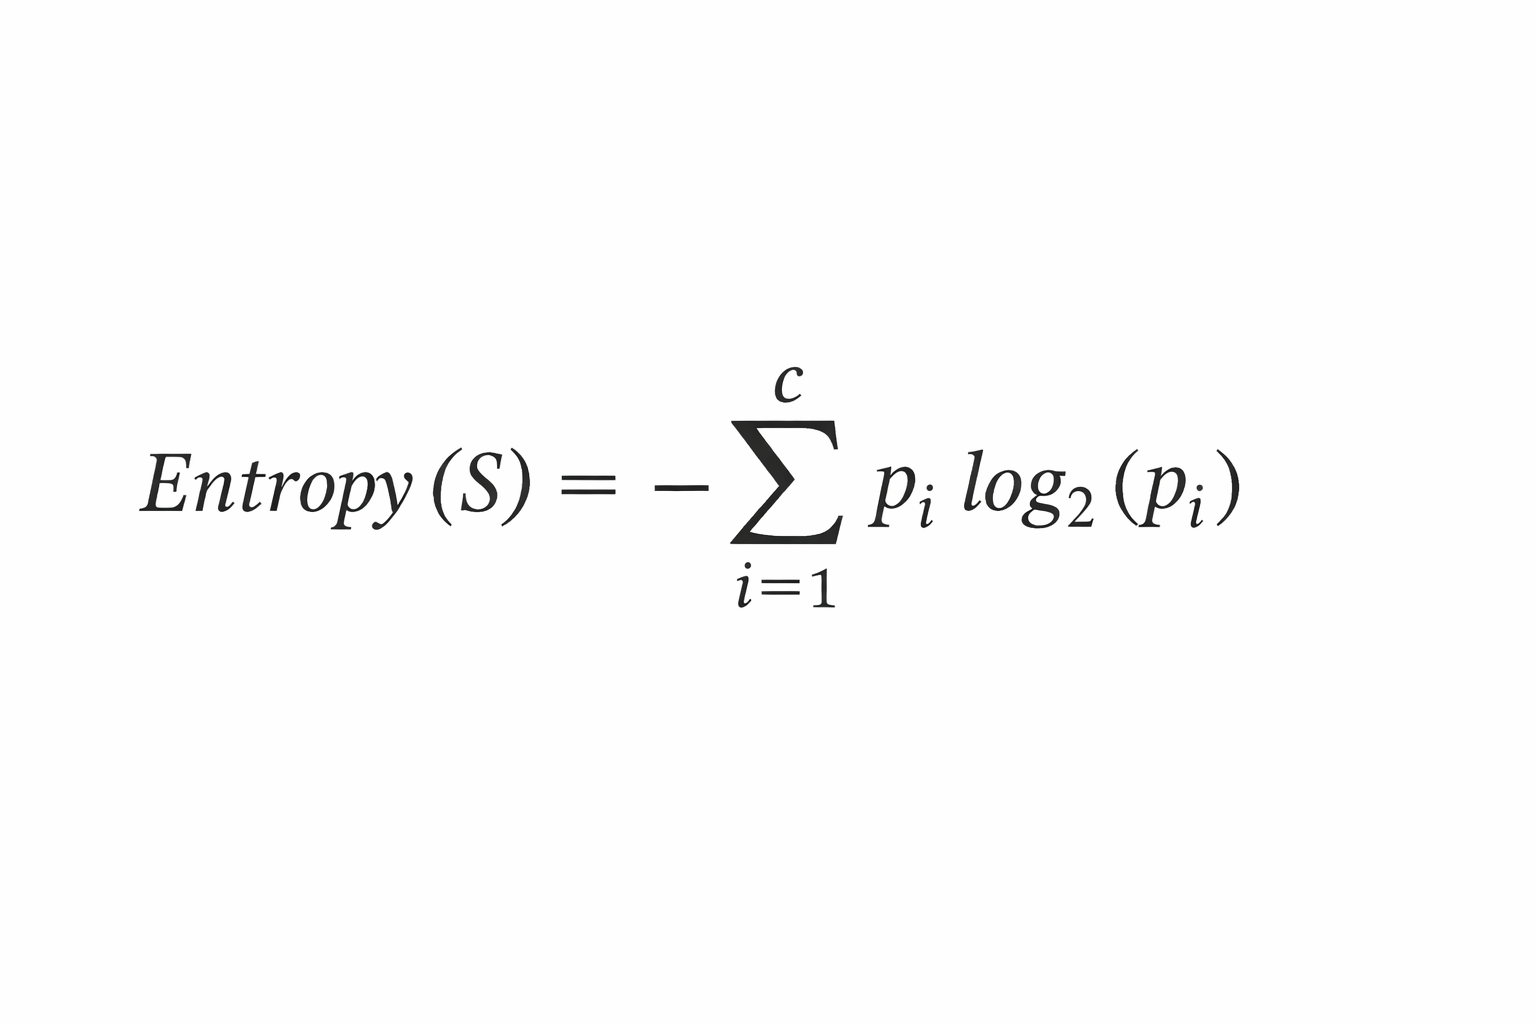

   Where:
     - 𝑝𝑖 = probability of class i

🔹 Range
         Entropy	   Meaning
            0	        Pure
            1	      Maximum disorder


🔹 Example
   - Dataset:
       - 4 Yes
       - 4 No

       p(Yes)=0.5,p(No)=0.5
       Entropy=−0.5log2​(0.5)−0.5log2​(0.5)=1


5️⃣ Information Gain:
📌 Definition:
    - Measures reduction in entropy after split.

Formula:
![information gain.png](<attachment:information gain.png>)


6️⃣ Gini Index

📌 Definition:
   - Measures probability of misclassification.

Formula:
![gini index.png](<attachment:gini index.png>)

 🔹 Range:

        Gini	Meaning
          0	     Pure
          0.5	Impure

  🔹 Example:
             Gini=1−(0.52+0.52)=0.5


8️⃣ Tree Building Algorithm
ID3 (Entropy based)

Steps:

Calculate entropy

Compute information gain

Pick best feature

Split

Repeat

CART (Gini based)

Steps:

Calculate Gini

Pick lowest Gini

Binary splits only

9️⃣ Pruning
📌 Definition

Pruning removes unnecessary branches to avoid overfitting.

Without pruning:
❌ Tree memorizes data
❌ Poor test accuracy

With pruning:
✅ Better generalization
✅ Smaller tree

Types of Pruning:

🔹 Pre-Pruning (Early Stopping): 
   Stop tree growth early.

    Methods:
        - max_depth
        - min_samples_split
        - min_samples_leaf
        - min_gain
        
    Example:
         max_depth = 3
        Stops after depth 3.


🔹 Post-Pruning:
  Grow full tree → then remove weak branches.

   Steps:
     1. Build complete tree
     2. Remove nodes with low accuracy
     3. Validate performance

    
Cost Complexity Pruning:
Used in CART:
             Cost=Error+α×TreeSize


Where:
      α = regularization parameter
  Higher α → smaller tree


10️⃣ Advantages:
    -  Easy to understand
    - No scaling required
    - Works for numeric + categorical
    - Handles missing values
    - Visualizable


11️⃣ Disadvantages:
    - Overfitting
    - Unstable to small data change
    - Biased to features with many values
    - Large trees slow
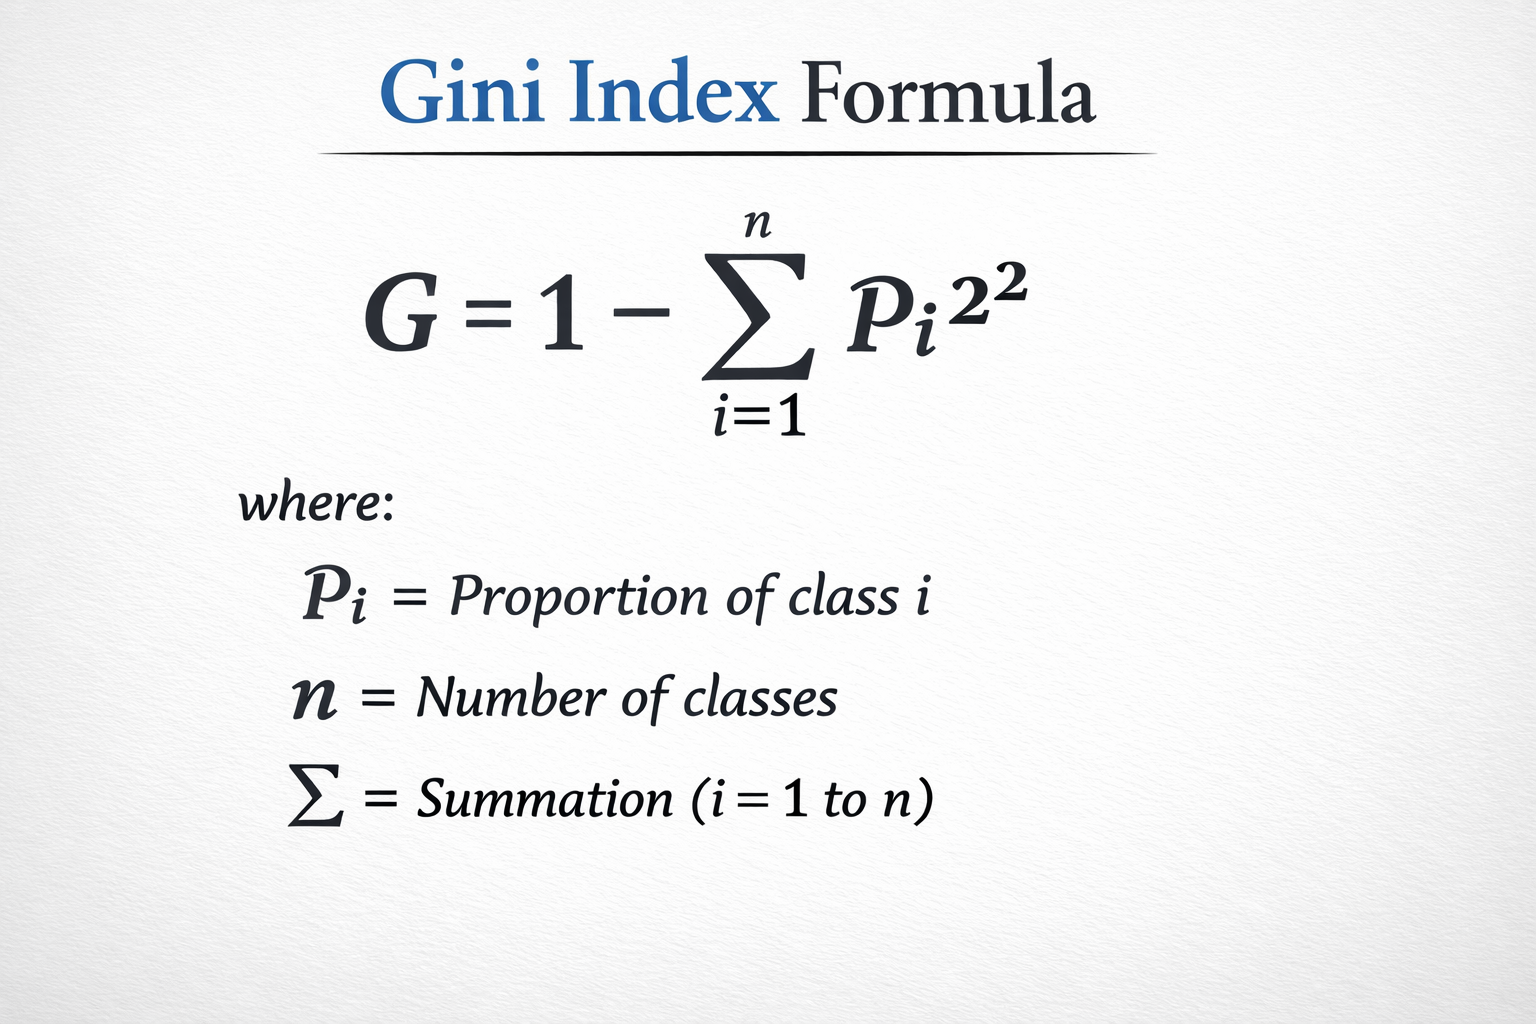
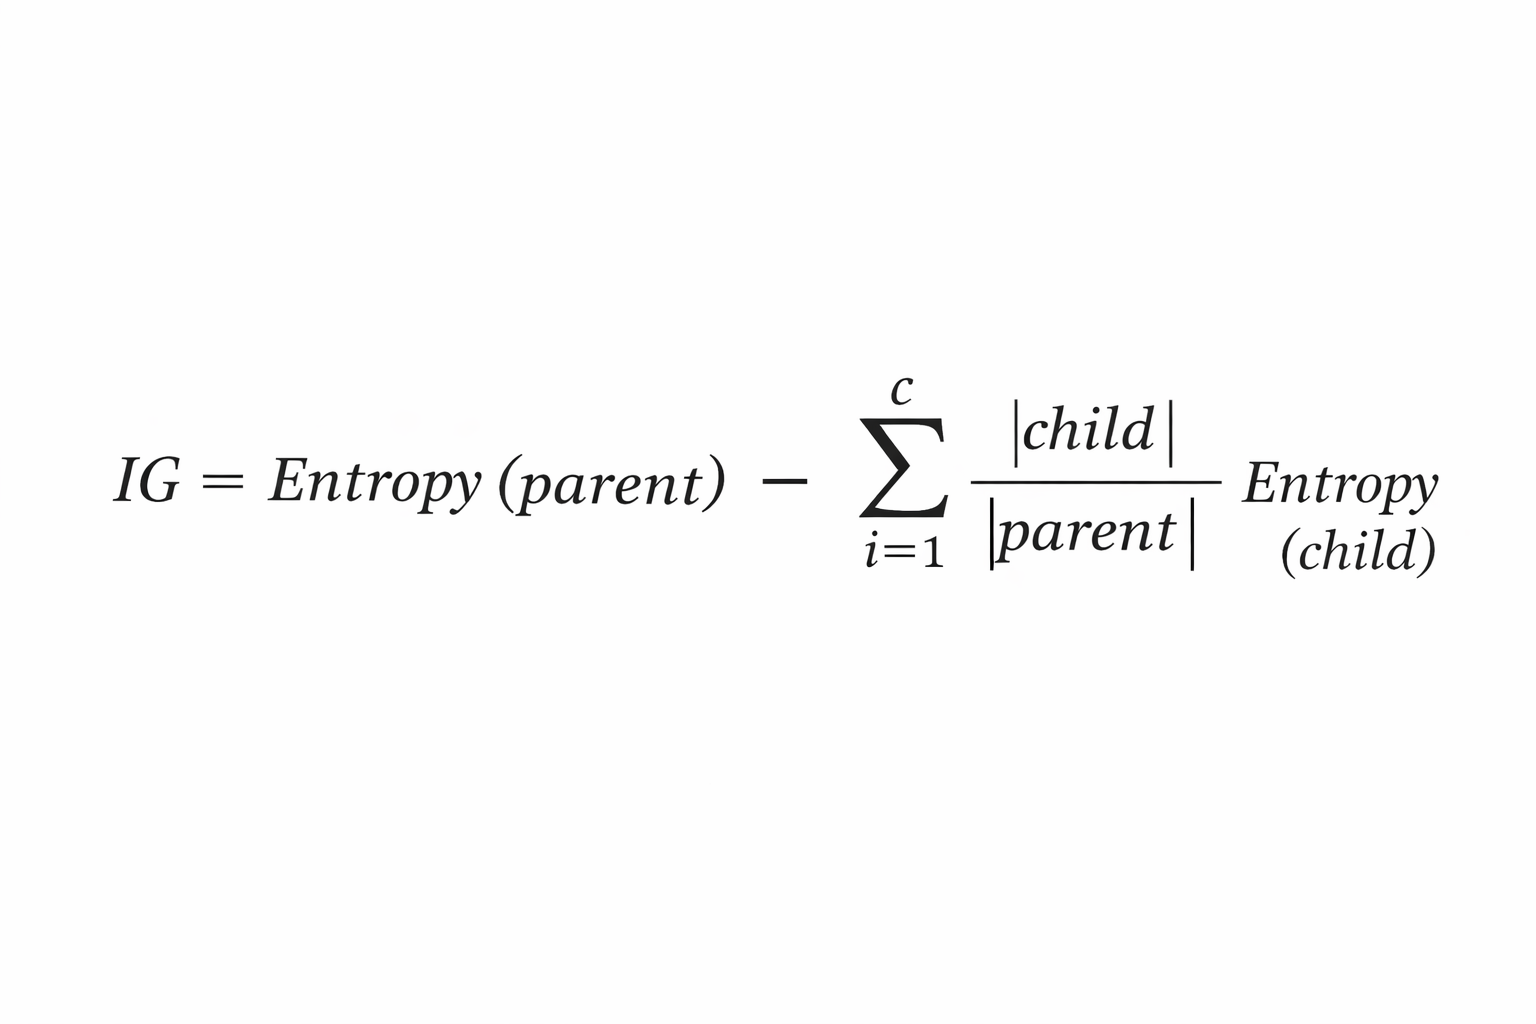

In [1]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import datasets

data = datasets.load_iris()
X = data.data
y = data.target

model = DecisionTreeClassifier(
    criterion="gini",   # or entropy
    max_depth=3
)

model.fit(X, y)

print("Accuracy:", model.score(X, y))

Accuracy: 0.9733333333333334


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("petrol consumption.csv")
df.head()

,Petrol_tax,Average_income,Paved_Highways,Population_Driver_licence(%),Petrol_Consumption
0,9.0,3571,1976,0.525,541
1,9.0,4092,1250,0.572,524
2,9.0,3865,1586,0.580,561
3,7.5,4870,2351,0.529,414
4,8.0,4399,431,0.544,410


In [8]:
x = df.drop("Petrol_Consumption", axis = 1)
y = df['Petrol_Consumption']

In [10]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y,
                                                   random_state= 0)

In [11]:
from sklearn.tree import DecisionTreeRegressor

In [12]:
dt = DecisionTreeRegressor(random_state= 0)

In [13]:
dt.fit(x_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_le

In [14]:
y_pred= dt.predict(x_test)

In [15]:
from sklearn.metrics import mean_absolute_error, r2_score

In [16]:
mean_absolute_error(y_test, y_pred)

22.6

In [17]:
r2_score(y_test, y_pred)

0.893209316822986

In [18]:
dt.score(x, y)

0.958344271128366

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [53]:
df = pd.read_csv('movies.csv')
df

,Movie,Budget,Celebrities_num,Class
0,Fight Club,284000000,9.0,Critical Success
1,Batman Begins,348000000,7.0,Critical Success
2,The Big Lebowski,452000000,10.0,Critical Success
3,Snatch,585000000,9.0,Critical Success
4,"The Good, the Bad and the Ugly",712000000,10.0,Critical Success
5,Gladiator,887000000,5.5,Mainstream Hit
6,Saving Private Ryan,814500000,4.0,Mainstream Hit
7,Amélie,894500000,4.0,Mainstream Hit
8,American History X,1100000000,7.0,Mainstream Hit
9,In Bruges,795600000,8.0,Mainstream Hit


In [54]:
df.shape

(20, 4)

In [55]:
df.columns

Index(['Movie', 'Budget', 'Celebrities_num', 'Class'], dtype='object')

<!-- visualize -->

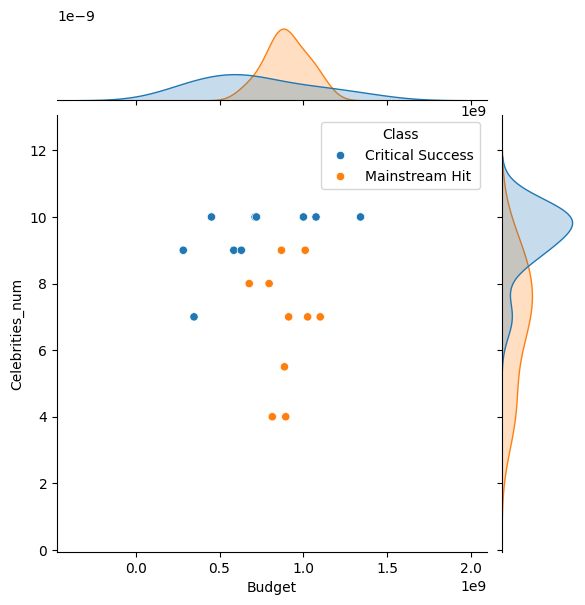

In [57]:
sns.jointplot(x = 'Budget', y = 'Celebrities_num', data = df,
             hue = 'Class')

In [60]:
x = df[['Budget', 'Celebrities_num']]
y = df['Class']

In [61]:
from sklearn.tree import DecisionTreeClassifier

In [62]:
dt = DecisionTreeClassifier(random_state= 0)

In [63]:
dt.fit(x, y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

# 540000000, 3
# 344000000, 10

In [64]:
dt.predict([[540000000, 3]])


c:\INTERNSHIP\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array(['Mainstream Hit'], dtype=object)

In [65]:
dt.predict([[344000000, 10]])

c:\INTERNSHIP\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array(['Critical Success'], dtype=object)